<a href="https://colab.research.google.com/github/gauravjha201/Machine-learning-basics/blob/main/K_means_Clustering.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline
from sklearn.datasets import make_blobs


In [ ]:
x,y=make_blobs(n_samples=1000,n_features=2,centers=3)
x

array([[ 4.39757193, -4.95220771],
       [ 5.73412236, -2.40877125],
       [ 3.49393425, -3.83229128],
       ...,
       [-2.83602211, -5.37752897],
       [-2.86500261, -6.58389586],
       [ 0.23699426,  2.43544477]])

In [ ]:
y

array([0, 0, 0, 2, 0, 0, 2, 2, 0, 2, 0, 1, 0, 0, 2, 1, 1, 2, 1, 2, 0, 1,
       2, 1, 1, 1, 0, 2, 2, 2, 1, 0, 1, 0, 1, 1, 2, 0, 2, 2, 0, 0, 0, 2,
       0, 0, 2, 0, 1, 2, 1, 2, 0, 1, 1, 1, 1, 2, 0, 2, 0, 1, 1, 2, 1, 2,
       1, 0, 0, 2, 0, 1, 0, 2, 1, 0, 0, 2, 0, 0, 0, 0, 1, 1, 0, 2, 2, 1,
       2, 0, 2, 2, 0, 2, 1, 1, 2, 2, 1, 2, 2, 2, 0, 2, 2, 0, 0, 1, 2, 0,
       2, 1, 0, 1, 1, 2, 0, 1, 2, 2, 1, 0, 2, 0, 1, 1, 2, 1, 2, 1, 2, 1,
       0, 1, 1, 2, 2, 0, 1, 2, 0, 2, 2, 1, 2, 2, 0, 1, 2, 2, 1, 0, 0, 2,
       1, 2, 0, 1, 1, 1, 1, 2, 1, 1, 2, 0, 1, 0, 0, 0, 0, 1, 1, 2, 1, 2,
       2, 2, 2, 0, 2, 2, 1, 1, 1, 2, 0, 0, 2, 1, 0, 1, 1, 1, 1, 1, 1, 2,
       0, 1, 1, 2, 0, 2, 2, 1, 2, 0, 1, 0, 0, 0, 0, 1, 1, 1, 0, 2, 2, 0,
       0, 0, 1, 0, 1, 0, 1, 2, 1, 0, 2, 0, 1, 1, 0, 0, 0, 1, 2, 2, 2, 0,
       0, 2, 0, 2, 0, 2, 1, 1, 0, 1, 0, 0, 2, 0, 2, 0, 1, 2, 2, 2, 1, 0,
       2, 2, 2, 2, 0, 0, 1, 0, 2, 2, 2, 0, 1, 2, 1, 1, 0, 2, 1, 2, 0, 1,
       0, 0, 0, 1, 1, 2, 0, 1, 0, 2, 0, 1, 1, 1, 1,

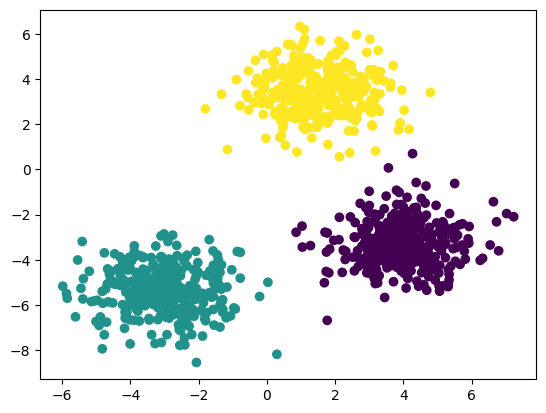

In [ ]:
plt.scatter(x[:,0],x[:,1],c=y)

In [ ]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.33,random_state=42)


In [ ]:
from sklearn.preprocessing import StandardScaler
scaler=StandardScaler()
x_train_scaled=scaler.fit_transform(x_train)
x_test_scaled=scaler.transform(x_test)



In [ ]:
from sklearn.cluster import KMeans
#Elbow method to select k
wcss=[]
for k in range(1,11):
  kmeans=KMeans(n_clusters=k,init="k-means++")
  kmeans.fit(x_train_scaled)
  wcss.append(kmeans.inertia_)

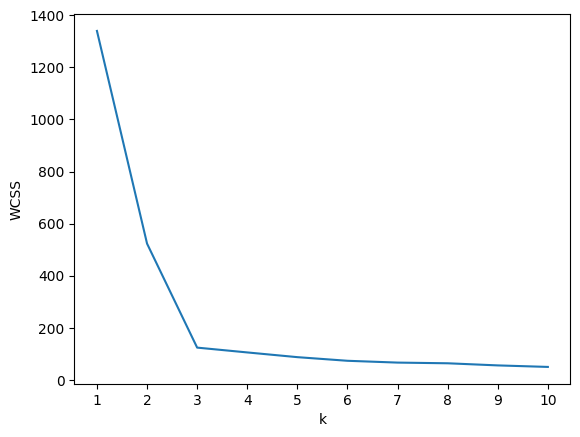

In [ ]:
plt.plot(range(1,11),wcss)
plt.xticks(range(1,11))
plt.xlabel("k")
plt.ylabel("WCSS")
plt.show()

In [ ]:
kmeans=KMeans(n_clusters=3,init="k-means++")
kmeans.fit(x_train_scaled)

KMeans(n_clusters=3)

In [ ]:
y_pred=kmeans.predict(x_test_scaled)
from sklearn.metrics import accuracy_score,classification_report,confusion_matrix,r2_score
print(accuracy_score(y_pred,y_test))
print(classification_report(y_pred,y_test))
print(confusion_matrix(y_pred,y_test))

1.0
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       121
           1       1.00      1.00      1.00       100
           2       1.00      1.00      1.00       109

    accuracy                           1.00       330
   macro avg       1.00      1.00      1.00       330
weighted avg       1.00      1.00      1.00       330

[[121   0   0]
 [  0 100   0]
 [  0   0 109]]


In [ ]:
  #Validating the k value# these are the method for finding best value for k(cluster)
  #kneelocator
  #Silhoutee scoring

In [ ]:
!pip install kneed

In [ ]:
#kneelocator

from kneed import KneeLocator
kl=KneeLocator(range(1,11),wcss,curve="convex",direction="decreasing")

In [ ]:
kl.elbow

np.int64(3)

In [ ]:
from sklearn.metrics import silhouette_score
silhouette_coefficients=[]
for k in range(2,11):
  kmeans=KMeans(n_clusters=k,init="k-means++")
  kmeans.fit(x_train_scaled)
  score=silhouette_score(x_train_scaled,kmeans.labels_)
  silhouette_coefficients.append(score)


In [ ]:
silhouette_coefficients

[np.float64(0.49488232427533047),
 np.float64(0.7352426961522583),
 np.float64(0.5915832599797333),
 np.float64(0.4647422557686964),
 np.float64(0.4597427801760424),
 np.float64(0.35720158310863565),
 np.float64(0.3521919553034754),
 np.float64(0.34847654124085464),
 np.float64(0.3402488817004683)]

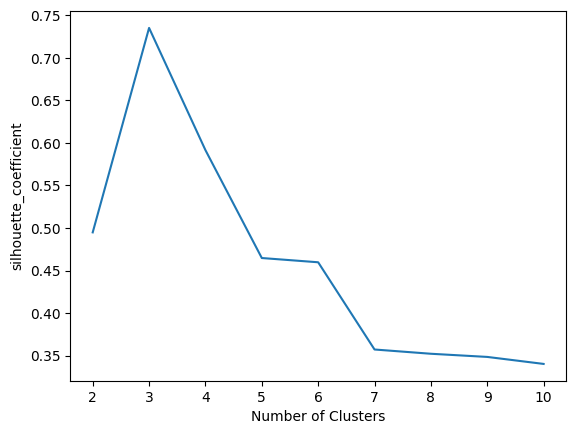

In [ ]:
plt.plot(range(2,11),silhouette_coefficients)
plt.xticks()
plt.xlabel("Number of Clusters")
plt.ylabel("silhouette_coefficient")
plt.show()

In [ ]:
#so 3 is the appropiate number of cluster for kmeans cluster\
#because graph shows that Globle maxima of that